In [2]:
# feature engineering required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
train_df = pd.read_csv("../data/application_train.csv")

In [4]:
feature_df = train_df.copy()

In [6]:
feature_df = train_df.copy()

In [7]:
feature_df["CREDIT_INCOME_RATIO"] = (
    feature_df["AMT_CREDIT"] /
    feature_df["AMT_INCOME_TOTAL"]
)


In [8]:
feature_df["ANNUITY_INCOME_RATIO"] = (
    feature_df["AMT_ANNUITY"] /
    feature_df["AMT_INCOME_TOTAL"]
)

In [9]:
feature_df["INCOME_PER_PERSON"] = (
    feature_df["AMT_INCOME_TOTAL"] /
    feature_df["CNT_FAM_MEMBERS"]
)

In [10]:
feature_df["CREDIT_PER_PERSON"] = (
    feature_df["AMT_CREDIT"] /
    feature_df["CNT_FAM_MEMBERS"]
)

In [11]:
feature_df["YEARS_EMPLOYED"] = (
    abs(feature_df["DAYS_EMPLOYED"]) / 365
)

feature_df["EMPLOYMENT_RATIO"] = (
    feature_df["YEARS_EMPLOYED"] /
    (abs(feature_df["DAYS_BIRTH"]) / 365)
)

In [12]:
feature_df["AGE"] = (
    abs(feature_df["DAYS_BIRTH"]) / 365
)

In [13]:
feature_df["AGE_GROUP"] = pd.cut(
    feature_df["AGE"],
    bins=[20,30,40,50,60,70],
    labels=[
        "20-30",
        "30-40",
        "40-50",
        "50-60",
        "60-70"
    ]
)

In [14]:
feature_df["INCOME_GROUP"] = pd.qcut(
    feature_df["AMT_INCOME_TOTAL"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [15]:
feature_df["LOAN_BURDEN"] = (
    feature_df["AMT_ANNUITY"] /
    feature_df["AMT_CREDIT"]
)

In [16]:
feature_df["EXT_SOURCE_MEAN"] = (
    feature_df[
        [
            "EXT_SOURCE_1",
            "EXT_SOURCE_2",
            "EXT_SOURCE_3"
        ]
    ].mean(axis=1)
)

In [17]:
doc_cols = [
    col for col in feature_df.columns
    if "FLAG_DOCUMENT" in col
]

feature_df["TOTAL_DOCUMENTS"] = (
    feature_df[doc_cols].sum(axis=1)
)

In [18]:
flag_cols = [
    "FLAG_MOBIL",
    "FLAG_EMP_PHONE",
    "FLAG_WORK_PHONE",
    "FLAG_CONT_MOBILE",
    "FLAG_PHONE",
    "FLAG_EMAIL"
]

feature_df["TOTAL_CONTACT_FLAGS"] = (
    feature_df[flag_cols].sum(axis=1)
)

In [19]:
new_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "INCOME_PER_PERSON",
    "CREDIT_PER_PERSON",
    "YEARS_EMPLOYED",
    "EMPLOYMENT_RATIO",
    "AGE",
    "AGE_GROUP",
    "INCOME_GROUP",
    "LOAN_BURDEN",
    "EXT_SOURCE_MEAN",
    "TOTAL_DOCUMENTS",
    "TOTAL_CONTACT_FLAGS"
]

feature_df[new_features].head()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,INCOME_PER_PERSON,CREDIT_PER_PERSON,YEARS_EMPLOYED,EMPLOYMENT_RATIO,AGE,AGE_GROUP,INCOME_GROUP,LOAN_BURDEN,EXT_SOURCE_MEAN,TOTAL_DOCUMENTS,TOTAL_CONTACT_FLAGS
0,2.007889,0.121978,202500.0,406597.50,1.745205,0.067329,25.920548,20-30,High,0.060749,0.161787,1,4
1,4.790750,0.132217,135000.0,646751.25,3.254795,0.070862,45.931507,40-50,Very High,0.027598,0.466757,1,4
2,2.000000,0.100000,67500.0,135000.00,0.616438,0.011814,52.180822,50-60,Very Low,0.050000,0.642739,0,5
3,2.316167,0.219900,67500.0,156341.25,8.326027,0.159905,52.068493,50-60,Low,0.094941,0.650442,1,3
4,4.222222,0.179963,121500.0,513000.00,8.323288,0.152418,54.608219,50-60,Low,0.042623,0.322738,1,3


In [22]:
from pathlib import Path

# Create output directory if it doesn't exist
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Save dataset
feature_df.to_csv(
    output_dir / "application_train_feature_engineered.csv",
    index=False
)

print("✅ Dataset saved successfully!")
print("Location:", (output_dir / "application_train_feature_engineered.csv").resolve())

✅ Dataset saved successfully!
Location: D:\Credit-Risk-Prediction\data\processed\application_train_feature_engineered.csv


In [4]:
from pathlib import Path
import pandas as pd

# Path to processed data
processed_data_path = Path("../data/processed")

# Load feature engineered dataset
feature_df = pd.read_csv(
    processed_data_path / "application_train_feature_engineered.csv"
)

print("Dataset Loaded Successfully!")
print(feature_df.shape)

feature_df.head()

Dataset Loaded Successfully!
(307511, 135)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CREDIT_PER_PERSON,YEARS_EMPLOYED,EMPLOYMENT_RATIO,AGE,AGE_GROUP,INCOME_GROUP,LOAN_BURDEN,EXT_SOURCE_MEAN,TOTAL_DOCUMENTS,TOTAL_CONTACT_FLAGS
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,406597.50,1.745205,0.067329,25.920548,20-30,High,0.060749,0.161787,1,4
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,646751.25,3.254795,0.070862,45.931507,40-50,Very High,0.027598,0.466757,1,4
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,135000.00,0.616438,0.011814,52.180822,50-60,Very Low,0.050000,0.642739,0,5
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,156341.25,8.326027,0.159905,52.068493,50-60,Low,0.094941,0.650442,1,3
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,513000.00,8.323288,0.152418,54.608219,50-60,Low,0.042623,0.322738,1,3


In [8]:
# Missing values count
missing_count = feature_df.isnull().sum().sum()

missing_count

np.int64(9152665)

In [11]:
# Missing value percentage
missing_percentage = (
    feature_df.isnull().mean().sum() * 100
).round(2)

missing_percentage

np.float64(2976.37)

In [15]:
missing_summary = pd.DataFrame({
    "Missing Count": feature_df.isnull().sum(),
    "Missing Percentage": (
        feature_df.isnull().mean() * 100
    ).round(2),
    "Data Type": feature_df.dtypes
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage,Data Type
COMMONAREA_MEDI,214865,69.87,float64
COMMONAREA_AVG,214865,69.87,float64
COMMONAREA_MODE,214865,69.87,float64
NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
...,...,...,...
AGE,0,0.00,float64
INCOME_GROUP,0,0.00,str
LOAN_BURDEN,12,0.00,float64
TOTAL_DOCUMENTS,0,0.00,int64


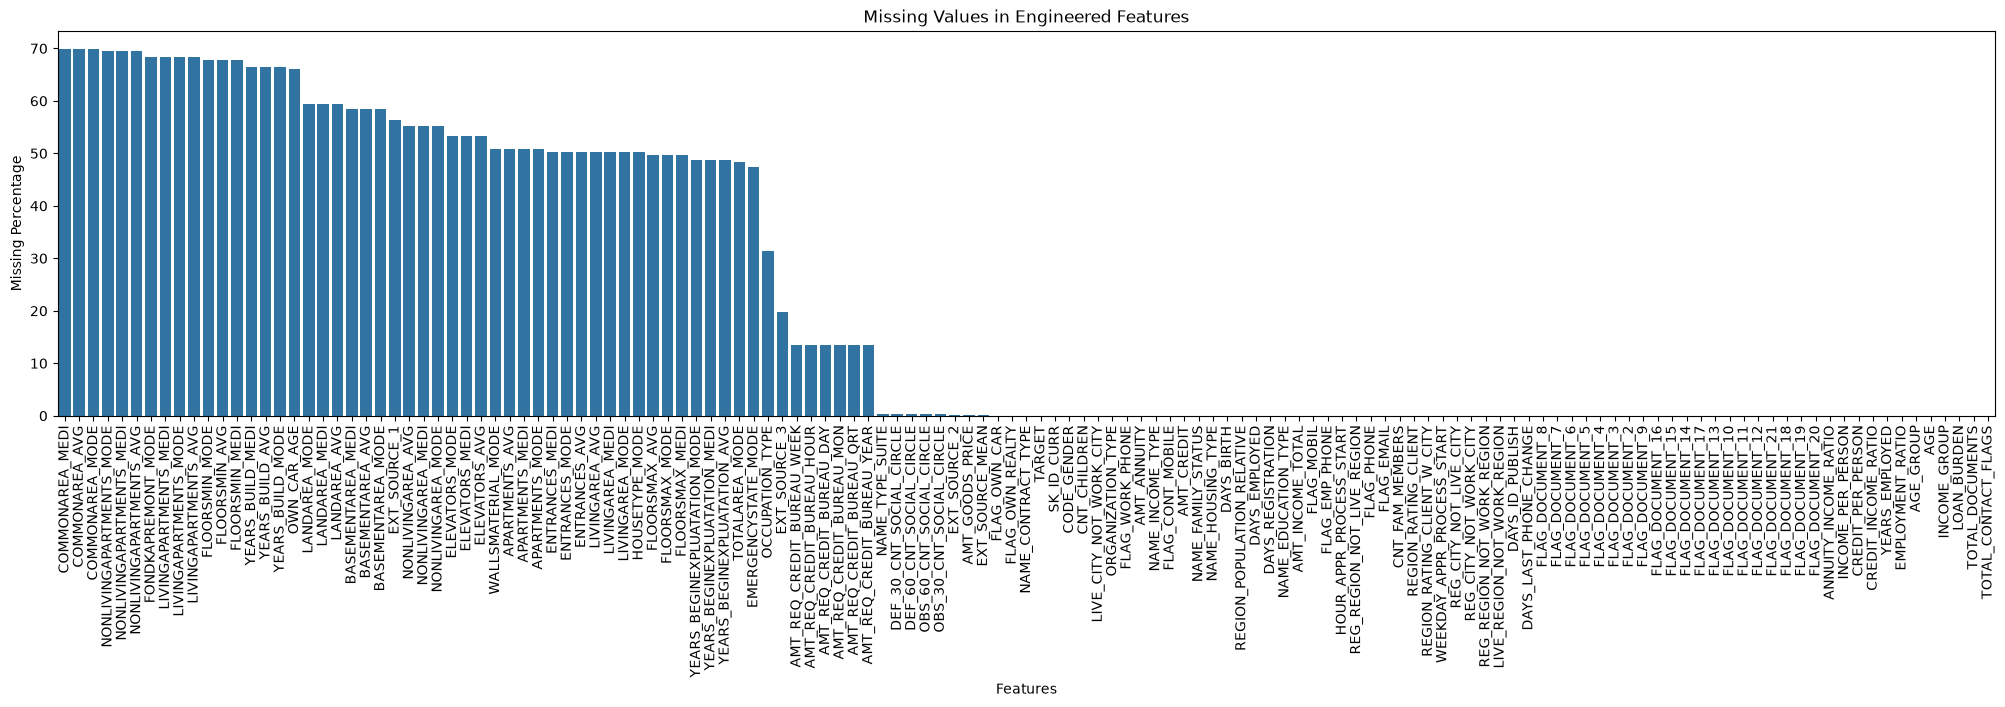

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(25,5))

sns.barplot(
    x=missing_summary.index,
    y="Missing Percentage",
    data=missing_summary
)

plt.xticks(rotation=90)

plt.ylabel("Missing Percentage")

plt.xlabel("Features")

plt.title("Missing Values in Engineered Features")

plt.show()

In [24]:
missing_features = missing_summary[
    missing_summary["Missing Count"] > 0
]

missing_features

,Missing Count,Missing Percentage,Data Type
COMMONAREA_MEDI,214865,69.87,float64
COMMONAREA_AVG,214865,69.87,float64
COMMONAREA_MODE,214865,69.87,float64
NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
...,...,...,...
DAYS_LAST_PHONE_CHANGE,1,0.00,float64
ANNUITY_INCOME_RATIO,12,0.00,float64
INCOME_PER_PERSON,2,0.00,float64
CREDIT_PER_PERSON,2,0.00,float64


In [25]:
print("No missing values found.")

No missing values found.


In [27]:
num_cols = feature_df.select_dtypes(include=["number"]).columns

feature_df[num_cols] = feature_df[num_cols].fillna(
    feature_df[num_cols].median()
)

In [33]:
new_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "INCOME_PER_PERSON",
    "CREDIT_PER_PERSON",
    "YEARS_EMPLOYED",
    "EMPLOYMENT_RATIO",
    "AGE",
    "AGE_GROUP",
    "INCOME_GROUP",
    "LOAN_BURDEN",
    "EXT_SOURCE_MEAN",
    "TOTAL_DOCUMENTS",
    "TOTAL_CONTACT_FLAGS"
]

In [34]:
missing_summary = pd.DataFrame({
    "Missing Count": feature_df[new_features].isnull().sum(),
    "Missing Percentage": (
        feature_df[new_features].isnull().mean() * 100
    ).round(4),
    "Data Type": feature_df[new_features].dtypes
})

missing_summary = missing_summary.sort_values(
    by="Missing Count",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage,Data Type
CREDIT_INCOME_RATIO,0,0.0,float64
ANNUITY_INCOME_RATIO,0,0.0,float64
INCOME_PER_PERSON,0,0.0,float64
CREDIT_PER_PERSON,0,0.0,float64
YEARS_EMPLOYED,0,0.0,float64
EMPLOYMENT_RATIO,0,0.0,float64
AGE,0,0.0,float64
AGE_GROUP,0,0.0,str
INCOME_GROUP,0,0.0,str
LOAN_BURDEN,0,0.0,float64


In [35]:
missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing Percentage,Data Type


In [36]:
# Check missing values
feature_df[new_features].isnull().sum()

CREDIT_INCOME_RATIO     0
ANNUITY_INCOME_RATIO    0
INCOME_PER_PERSON       0
CREDIT_PER_PERSON       0
YEARS_EMPLOYED          0
EMPLOYMENT_RATIO        0
AGE                     0
AGE_GROUP               0
INCOME_GROUP            0
LOAN_BURDEN             0
EXT_SOURCE_MEAN         0
TOTAL_DOCUMENTS         0
TOTAL_CONTACT_FLAGS     0
dtype: int64

In [37]:
feature_df.describe

<bound method NDFrame.describe of         SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0           100002       1         Cash loans           M            N   
1           100003       0         Cash loans           F            N   
2           100004       0    Revolving loans           M            Y   
3           100006       0         Cash loans           F            N   
4           100007       0         Cash loans           M            N   
...            ...     ...                ...         ...          ...   
307506      456251       0         Cash loans           M            N   
307507      456252       0         Cash loans           F            N   
307508      456253       0         Cash loans           F            N   
307509      456254       1         Cash loans           F            N   
307510      456255       0         Cash loans           F            N   

       FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  \
0      

In [38]:
feature_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 135 entries, SK_ID_CURR to TOTAL_CONTACT_FLAGS
dtypes: float64(74), int64(43), str(18)
memory usage: 365.6 MB


In [40]:
feature_df.isnull().sum().sum()

np.int64(0)

In [45]:
important_original_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "REGION_POPULATION_RELATIVE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE"
]

In [46]:
new_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "INCOME_PER_PERSON",
    "CREDIT_PER_PERSON",
    "YEARS_EMPLOYED",
    "EMPLOYMENT_RATIO",
    "AGE",
    "AGE_GROUP",
    "INCOME_GROUP",
    "LOAN_BURDEN",
    "EXT_SOURCE_MEAN",
    "TOTAL_DOCUMENTS",
    "TOTAL_CONTACT_FLAGS"
]